# **Laboratorio Clase 4: LangChain, LangGraph y LangSmith**

Hoy construimos agentes paso a paso: primero cadenas simples, luego un agente con herramientas, luego un grafo con estado. Al final todo queda trazado en LangSmith.

## Sección 1 — Instalación y configuración

In [41]:
# Solo necesitas ejecutar esto una vez
!pip install -q langchain langchain-openai langgraph langsmith


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [42]:
import os
import logging

# ── OBLIGATORIO ──────────────────────────────────────────
os.environ["OPENAI_API_KEY"] = "TU_OPENAI_API_KEY"   # tu clave de OpenAI


In [ ]:

# Desactiva LangSmith y suprime los errores 403 si quedó activo de sesiones anteriores
os.environ["LANGSMITH_TRACING"] = "false"
os.environ.pop("LANGSMITH_API_KEY", None)
logging.getLogger("langsmith").setLevel(logging.CRITICAL)

print("Listo.")

Listo.


### LangSmith — opcional (solo para trazas y evaluación)

LangSmith es la herramienta de observabilidad nativa de LangChain. Equivalente a lo que vimos con **Langfuse** y **Arize Phoenix** en clases anteriores, pero integrada de serie con todo el stack LangChain/LangGraph.

Si lo activas, **todas las ejecuciones de este notebook aparecerán automáticamente** en [smith.langchain.com](https://smith.langchain.com) — sin cambiar ninguna línea de código.

Si no lo activas, el notebook funciona exactamente igual. Solo te pierdes las trazas.

> **Importante:** para activarlo, reinicia el kernel y ejecuta la celda de LangSmith **antes** de cualquier otra. Si no, puede quedar desactivado de la celda anterior.

In [44]:
# ── OPCIONAL: LangSmith ─────────────────────────────────
# Crea cuenta gratis en smith.langchain.com → copia tu API key
# Descomenta y ejecuta esta celda solo si quieres activar las trazas.

# os.environ["LANGSMITH_API_KEY"] = "lsv2_..."  # tu clave de LangSmith
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_PROJECT"] = "EBIS-lab"
# print("LangSmith activado — abre smith.langchain.com para ver las trazas.")

## Sección 2 — LangChain: cadenas con LCEL

El operador `|` encadena bloques: cada bloque pasa su salida al siguiente. No se ejecuta nada hasta `.invoke()`.

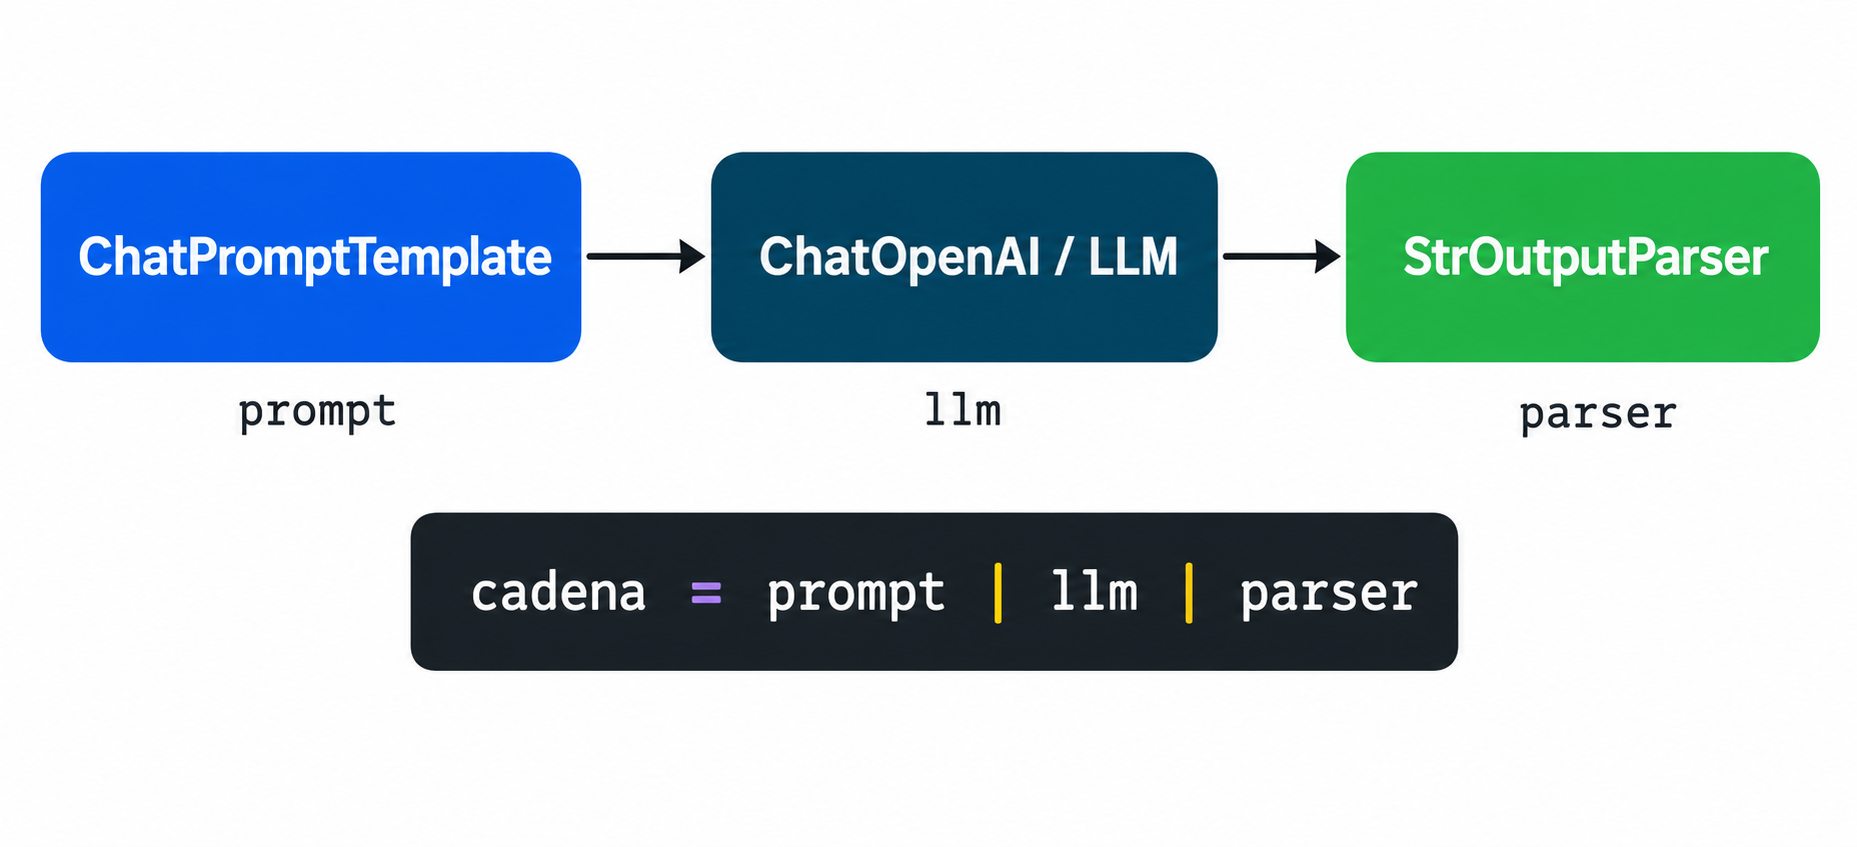

Cada bloque es independiente y reutilizable — puedes sustituir el LLM por otro modelo sin tocar el prompt ni el parser.

In [45]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

llm    = ChatOpenAI(model="gpt-4o-mini", temperature=0)
prompt = ChatPromptTemplate.from_template("Explica {tema} en 2 frases sencillas.")
parser = StrOutputParser()  # convierte la respuesta del modelo en un string limpio

cadena = prompt | llm | parser

print(cadena.invoke({"tema": "los embeddings vectoriales"}))

Los embeddings vectoriales son representaciones numéricas de palabras o elementos en un espacio multidimensional, donde palabras con significados similares están más cerca unas de otras. Esto permite que las máquinas comprendan y procesen el lenguaje de manera más efectiva, capturando relaciones semánticas y contextuales.


### Salida estructurada — primero, ¿qué es Pydantic?

Pydantic es una librería Python para **definir la forma exacta que debe tener un dato**.  
Defines una clase con campos y tipos, y Pydantic valida que lo que llega cuadre con el molde.

LangChain lo usa para decirle al modelo: *"devuélveme exactamente esto, con estos campos y estos tipos"*.

In [46]:
from pydantic import BaseModel

# Definimos un molde con campos y tipos
class Pelicula(BaseModel):
    titulo: str
    anyo: int
    puntuacion: float

p = Pelicula(titulo="Inception", anyo=2010, puntuacion=8.8)
print(p)
print(p.titulo, p.puntuacion)

# Descomentar para ver qué pasa si los tipos no cuadran:
# Pelicula(titulo="Test", anyo="dos mil", puntuacion=9.0)

titulo='Inception' anyo=2010 puntuacion=8.8
Inception 8.8


In [47]:
# Ahora usamos Pydantic con LangChain para que el modelo devuelva datos estructurados
class AnalisisSentimiento(BaseModel):
    sentimiento: str   # "positivo", "negativo" o "neutro"
    confianza: float   # entre 0.0 y 1.0
    razon: str         # una frase explicando el porqué

# with_structured_output le dice al modelo: "rellena este molde"
llm_s  = ChatOpenAI(model="gpt-4o-mini", temperature=0).with_structured_output(AnalisisSentimiento)
prompt_s = ChatPromptTemplate.from_template("Analiza el sentimiento:\n\n{texto}")
cadena_s = prompt_s | llm_s

textos = [
    "El modelo funciona increíble, estoy muy sorprendido por la velocidad.",
    "Llevo dos horas intentando instalarlo y sigue fallando. Pésimo.",
    "La documentación tiene 47 páginas.",
]

for texto in textos:
    r = cadena_s.invoke({"texto": texto})
    # r ya es un objeto Python — no hay json.loads(), no hay parseo manual
    print(f"[{r.sentimiento.upper()} {r.confianza:.0%}] {r.razon}")

c:\Users\alexo\AppData\Local\Programs\Python\Python39\lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=AnalisisSentimiento(senti... sentimiento positivo."), input_type=AnalisisSentimiento])
  return self.__pydantic_serializer__.to_python(


[POSITIVO 95%] El uso de palabras como 'increíble' y 'muy sorprendido' indica una fuerte satisfacción y admiración hacia el modelo, lo que refleja un sentimiento positivo.


c:\Users\alexo\AppData\Local\Programs\Python\Python39\lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=AnalisisSentimiento(senti...za su insatisfacción."), input_type=AnalisisSentimiento])
  return self.__pydantic_serializer__.to_python(


[NEGATIVO 95%] El usuario expresa frustración y descontento debido a la dificultad en la instalación, utilizando la palabra 'pésimo' que refuerza su insatisfacción.
[NEUTRAL 85%] La afirmación es objetiva y no expresa emociones ni juicios de valor.


c:\Users\alexo\AppData\Local\Programs\Python\Python39\lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=AnalisisSentimiento(senti...s ni juicios de valor.'), input_type=AnalisisSentimiento])
  return self.__pydantic_serializer__.to_python(


### Pipeline multi-paso — resumir y traducir en cadena

In [48]:
from langchain_core.runnables import RunnableLambda

prompt_resumen    = ChatPromptTemplate.from_template("Resume en 3 puntos clave:\n\n{texto}")
prompt_traduccion = ChatPromptTemplate.from_template("Traduce al inglés:\n\n{resumen}")
parser = StrOutputParser()

# RunnableLambda hace el mapeo entre la salida de un paso y el input del siguiente
pipeline = (
    prompt_resumen
    | llm
    | parser
    | RunnableLambda(lambda t: {"resumen": t})
    | prompt_traduccion
    | llm
    | parser
)

articulo = """
Los transformers revolucionaron el NLP en 2017. Su mecanismo de atención permite al modelo
relacionar cada token con todos los demás, capturando dependencias de largo alcance.
Hoy son la base de GPT, BERT y prácticamente todos los modelos modernos.
"""

print(pipeline.invoke({"texto": articulo}))

1. **Revolution in NLP**: Transformers, introduced in 2017, transformed natural language processing (NLP) by enabling a better understanding of context in text.

2. **Attention mechanism**: Their innovative attention mechanism allows each token to relate to all others, facilitating the capture of long-range dependencies in language.

3. **Foundation of modern models**: Transformers are the fundamental architecture behind advanced models like GPT and BERT, and are used in virtually all current NLP models.


## Sección 3 — Agente con herramientas

El agente decide **en cada paso** si necesita una herramienta, cuál y con qué argumentos.  
Tú defines las funciones. El modelo decide cuándo llamarlas.

In [49]:
from langchain_core.tools import tool
from typing import List
import random

@tool
def obtener_precio(ticker: str) -> str:
    """Devuelve el precio actual de una acción dado su ticker (ej: AAPL, MSFT, NVDA)."""
    precios = {"AAPL": 213.5, "GOOG": 178.2, "MSFT": 415.8, "NVDA": 118.3, "META": 590.1}
    return f"{ticker.upper()}: ${precios.get(ticker.upper(), round(random.uniform(50, 500), 2))}"

@tool
def calcular_cambio(precio_inicial: float, precio_final: float) -> str:
    """Calcula el porcentaje de cambio entre dos precios. precio_inicial es el precio antiguo, precio_final es el precio actual."""
    cambio = ((precio_final - precio_inicial) / precio_inicial) * 100
    return f"Cambio: {cambio:+.2f}%"

@tool
def comparar_acciones(tickers: List[str]) -> str:
    """Compara el precio actual de varias acciones. Recibe una lista de tickers como strings."""
    precios = {"AAPL": 213.5, "GOOG": 178.2, "MSFT": 415.8, "NVDA": 118.3, "META": 590.1}
    return " | ".join(f"{t.upper()}: ${precios.get(t.upper(), round(random.uniform(50,500),2))}" for t in tickers)

herramientas = [obtener_precio, calcular_cambio, comparar_acciones]
print("Tools:", [h.name for h in herramientas])

Tools: ['obtener_precio', 'calcular_cambio', 'comparar_acciones']


In [50]:
from langchain.agents import create_tool_calling_agent, AgentExecutor
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt_agente = ChatPromptTemplate.from_messages([
    ("system", "Eres un asistente financiero. Usa las herramientas para dar datos precisos. Llama primero a obtener_precio antes de calcular cambios."),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

agente   = create_tool_calling_agent(llm, herramientas, prompt_agente)
executor = AgentExecutor(agent=agente, tools=herramientas, verbose=True)

# verbose=True muestra el ciclo: razonar → tool → observar → razonar → respuesta final
resultado = executor.invoke({"input": "¿Cuánto vale AAPL ahora y cuánto ha subido desde 195?"})
print("\n→", resultado["output"])



> Entering new AgentExecutor chain...

Invoking: `obtener_precio` with `{'ticker': 'AAPL'}`


AAPL: $213.5
Invoking: `calcular_cambio` with `{'precio_inicial': 195, 'precio_final': 213.5}`


Cambio: +9.49%El precio actual de AAPL es de $213.5. Desde un precio de $195, ha subido un 9.49%.

> Finished chain.

→ El precio actual de AAPL es de $213.5. Desde un precio de $195, ha subido un 9.49%.


### Agente con memoria de conversación

In [51]:
from langchain_core.chat_history import InMemoryChatMessageHistory
from langchain_core.runnables.history import RunnableWithMessageHistory

store = {}

def get_history(session_id: str):
    if session_id not in store:
        store[session_id] = InMemoryChatMessageHistory()
    return store[session_id]

agente_memoria = RunnableWithMessageHistory(
    executor,
    get_history,
    input_messages_key="input",
    history_messages_key="chat_history",
)

config = {"configurable": {"session_id": "usuario-001"}}

r1 = agente_memoria.invoke({"input": "¿Cuánto vale NVDA ahora?"}, config=config)
print("Turno 1:", r1["output"])

# En el turno 2 no repetimos el ticker — el agente recuerda el contexto
r2 = agente_memoria.invoke({"input": "Y si hace 6 meses estaba a 78€, ¿cuánto ha subido?"}, config=config)
print("Turno 2:", r2["output"])



> Entering new AgentExecutor chain...


C:\Users\alexo\AppData\Roaming\Python\Python39\site-packages\IPython\core\interactiveshell.py:3550: LangChainPendingDeprecationWarning: RunnableWithMessageHistory is deprecated. Use LangGraph's built-in persistence instead.
  exec(code_obj, self.user_global_ns, self.user_ns)



Invoking: `obtener_precio` with `{'ticker': 'NVDA'}`


NVDA: $118.3El precio actual de NVDA (NVIDIA) es de $118.3.

> Finished chain.
Turno 1: El precio actual de NVDA (NVIDIA) es de $118.3.


> Entering new AgentExecutor chain...

Invoking: `obtener_precio` with `{'ticker': 'AAPL'}`


AAPL: $213.5
Invoking: `calcular_cambio` with `{'precio_inicial': 78, 'precio_final': 213.5}`


Cambio: +173.72%La acción de AAPL ha subido un **173.72%** desde hace 6 meses, cuando estaba a 78€.

> Finished chain.
Turno 2: La acción de AAPL ha subido un **173.72%** desde hace 6 meses, cuando estaba a 78€.


## Sección 4 — LangGraph: grafos con estado

En LangGraph el flujo ya no es lineal. Tienes **nodos** (funciones), **edges** (conexiones) y un **estado** compartido. Cada nodo lee el estado, hace su trabajo y escribe de vuelta. Nadie necesita conocer a los demás.

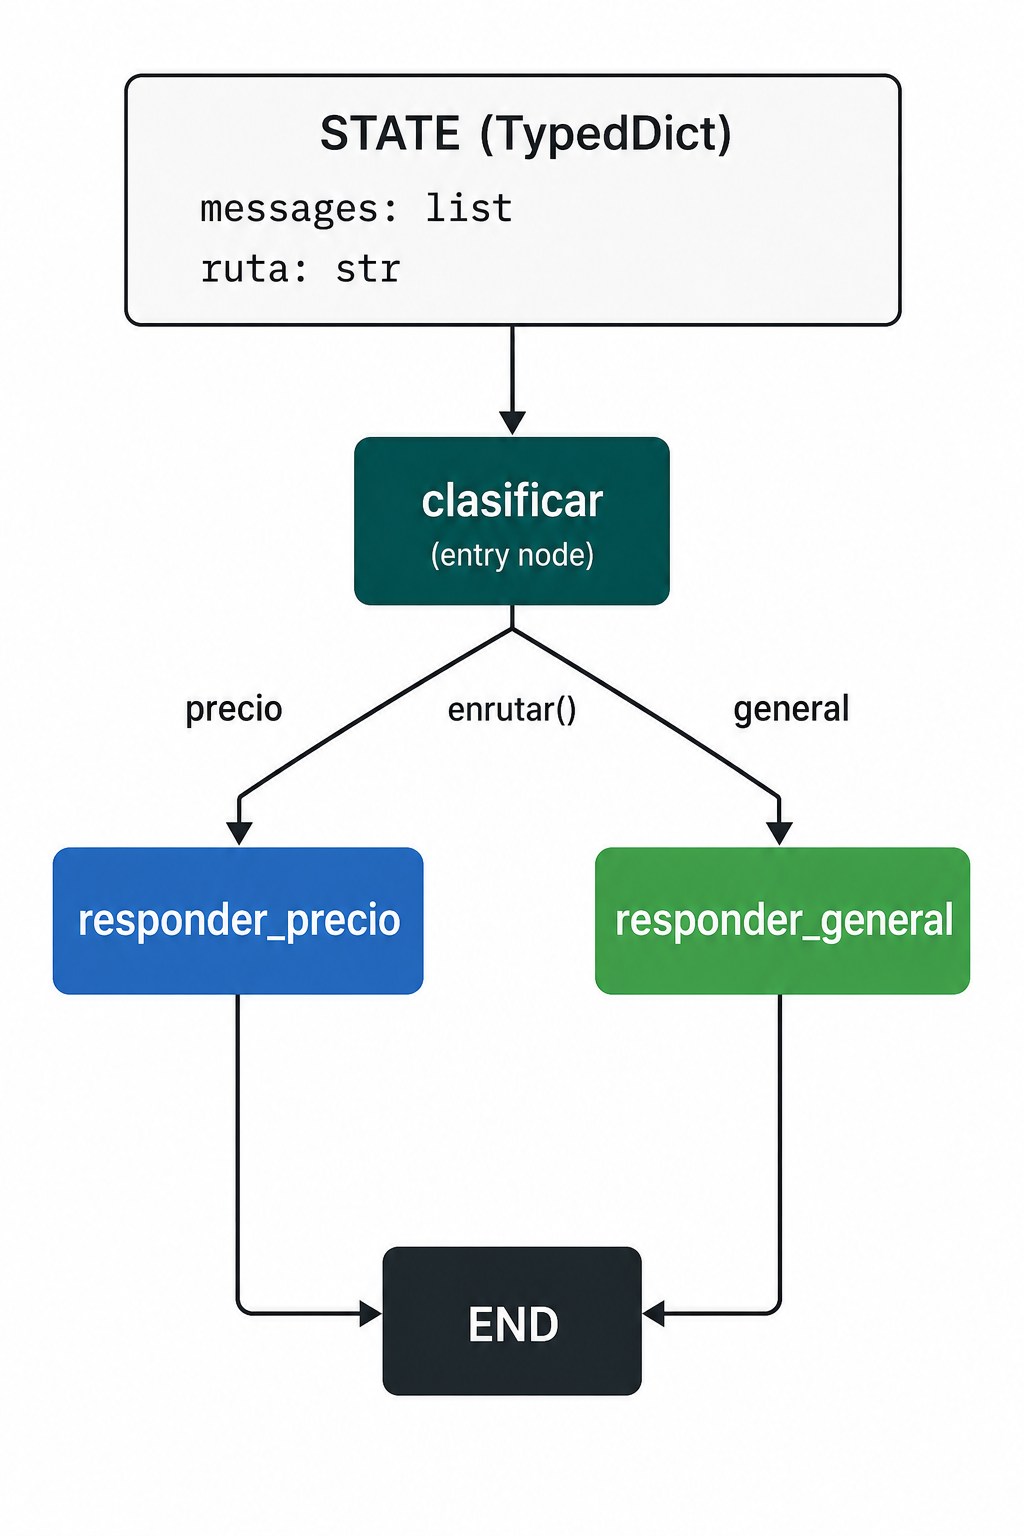

**La clave:** `enrutar()` lee `state["ruta"]` y devuelve el nombre del siguiente nodo. El grafo salta a ese nodo.

In [52]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, AIMessage

# El Estado es un diccionario compartido por todos los nodos.
# add_messages hace que los mensajes se acumulen en vez de sobrescribirse.
class Estado(TypedDict):
    messages: Annotated[list, add_messages]
    ruta: str  # decide a qué nodo ir después

# Nodo clasificador — lee la pregunta y decide la ruta
def clasificar(state: Estado) -> dict:
    pregunta = state["messages"][-1].content
    r = llm.invoke(f"Clasifica en una palabra: 'precio', 'comparar' o 'general'.\nPregunta: {pregunta}")
    ruta = r.content.strip().lower()
    if ruta not in ["precio", "comparar"]:
        ruta = "general"
    print(f"  → ruta: {ruta}")
    return {"ruta": ruta}

# Nodos de respuesta — cada uno hace una cosa concreta
def responder_precio(state: Estado) -> dict:
    return {"messages": [AIMessage(content="[Precio] AAPL: $213.5")]}

def responder_comparar(state: Estado) -> dict:
    return {"messages": [AIMessage(content="[Comparar] AAPL: $213.5 | MSFT: $415.8")]}

def responder_general(state: Estado) -> dict:
    r = llm.invoke(state["messages"][-1].content)
    return {"messages": [AIMessage(content=r.content)]}

# Función de enrutamiento — lee el estado y devuelve el nombre del siguiente nodo
def enrutar(state: Estado) -> str:
    return state["ruta"]

print("Nodos definidos.")

Nodos definidos.


In [53]:
g = StateGraph(Estado)

g.add_node("clasificar",      clasificar)
g.add_node("precio",          responder_precio)
g.add_node("comparar",        responder_comparar)
g.add_node("general",         responder_general)

g.set_entry_point("clasificar")

# Edge condicional: después de clasificar, enrutar() decide a qué nodo saltar
g.add_conditional_edges("clasificar", enrutar, {
    "precio":   "precio",
    "comparar": "comparar",
    "general":  "general",
})

g.add_edge("precio",   END)
g.add_edge("comparar", END)
g.add_edge("general",  END)

app = g.compile()
print("Grafo compilado.")

Grafo compilado.


In [54]:
preguntas = [
    "¿Cuánto vale Apple ahora mismo?",
    "Compara AAPL, MSFT y GOOG",
    "¿Qué es un ETF?",
]

for pregunta in preguntas:
    print(f"\n[?] {pregunta}")
    resultado = app.invoke({"messages": [HumanMessage(content=pregunta)], "ruta": ""})
    print(f"[→] {resultado['messages'][-1].content}")


[?] ¿Cuánto vale Apple ahora mismo?
  → ruta: general
[→] Lo siento, pero no tengo acceso a información en tiempo real, incluyendo el valor actual de las acciones de Apple. Te recomendaría que consultes una fuente financiera confiable o una plataforma de trading para obtener el precio más reciente de las acciones de Apple.

[?] Compara AAPL, MSFT y GOOG
  → ruta: general
[→] Claro, aquí tienes una comparación general de Apple Inc. (AAPL), Microsoft Corporation (MSFT) y Alphabet Inc. (GOOG), que es la empresa matriz de Google. Esta comparación se basa en varios aspectos clave:

### 1. **Modelo de Negocio**
- **Apple (AAPL)**: Se centra en el diseño, fabricación y venta de productos electrónicos de consumo, software y servicios. Sus productos más conocidos son el iPhone, iPad, Mac, Apple Watch y servicios como Apple Music y iCloud.
  
- **Microsoft (MSFT)**: Ofrece software, servicios y dispositivos. Es conocido por su sistema operativo Windows, la suite de productividad Office, y su pl

### Agente ReAct con LangGraph

`create_react_agent` construye el grafo ReAct completo en una línea. Internamente es un bucle — el mismo patrón que vimos en las slides de S3:

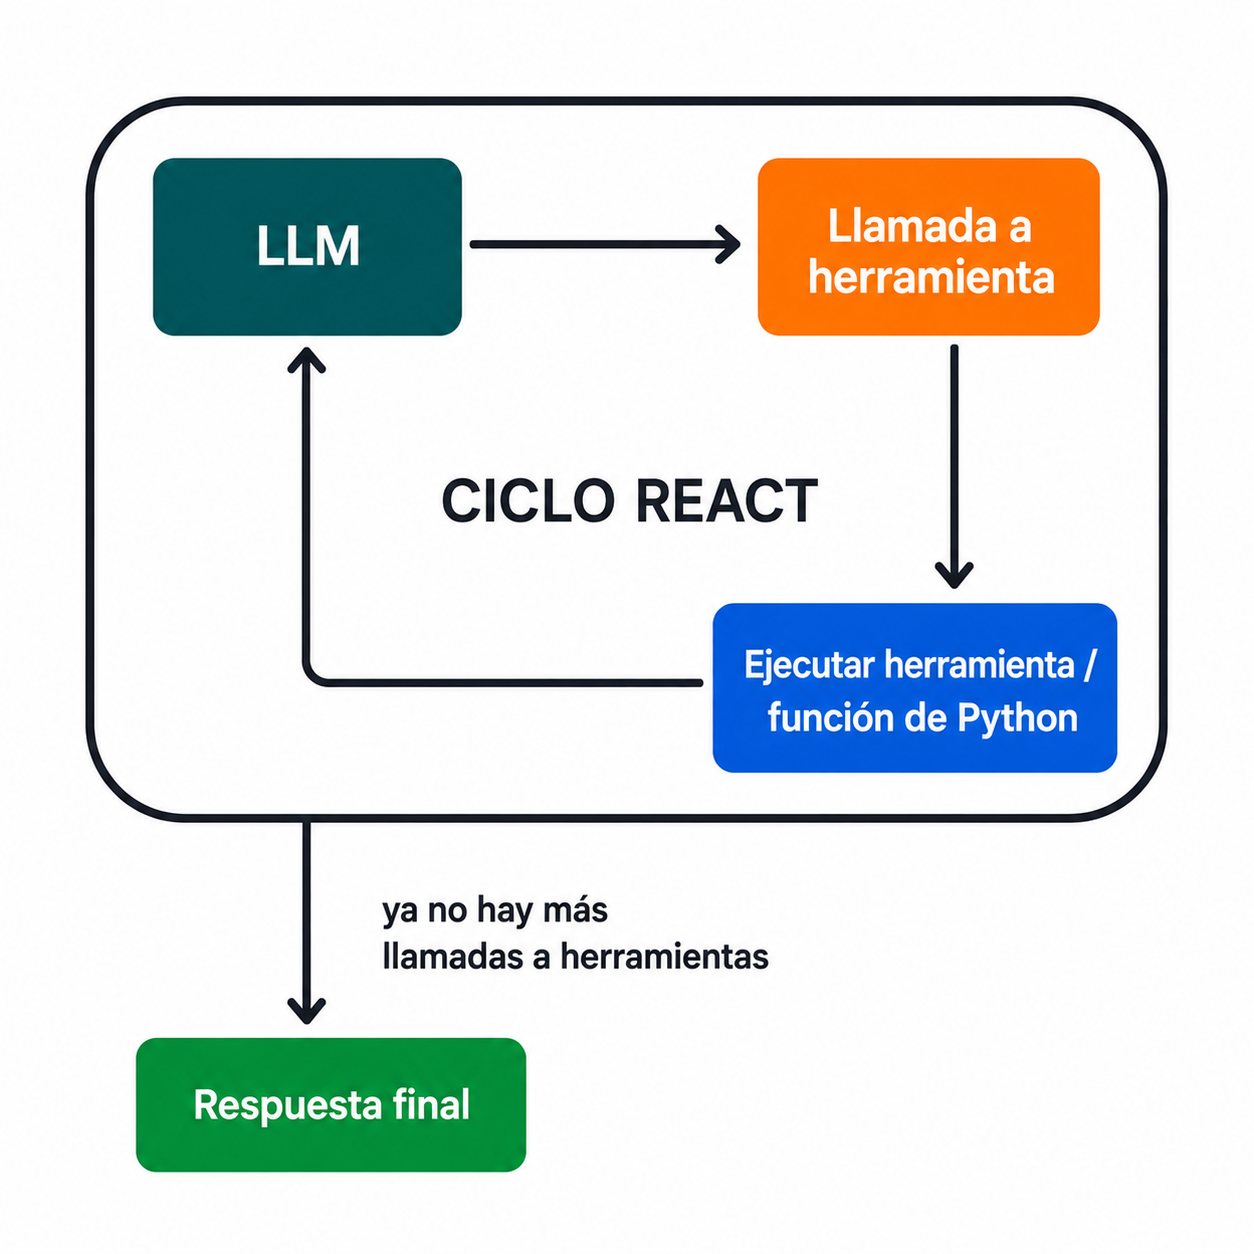

LLM → si llama a una tool → ejecutar → volver al LLM → repetir hasta respuesta final.

In [55]:
from langgraph.prebuilt import create_react_agent

agente_react = create_react_agent(
    model=ChatOpenAI(model="gpt-4o-mini", temperature=0),
    tools=herramientas,
    prompt="Eres un asistente financiero. Usa las herramientas para dar datos precisos.",
)

resultado = agente_react.invoke({
    "messages": [HumanMessage(content="¿Cuál es la diferencia porcentual entre AAPL y META?")]
})

for msg in resultado["messages"]:
    tipo     = type(msg).__name__
    contenido = msg.content if isinstance(msg.content, str) else str(msg.content)[:80]
    print(f"[{tipo}] {contenido[:120]}")

[HumanMessage] ¿Cuál es la diferencia porcentual entre AAPL y META?
[AIMessage] 
[ToolMessage] AAPL: $213.5
[ToolMessage] META: $590.1
[AIMessage] 
[ToolMessage] Cambio: +176.39%
[AIMessage] La diferencia porcentual entre el precio de las acciones de AAPL y META es del +176.39%. Esto significa que el precio de


## Sección 5 — Human-in-the-Loop

El grafo puede **pausarse** entre dos nodos y reanudarse cuando el humano aprueba. El estado queda guardado en un checkpoint — puede pasar horas entre la pausa y la reanudación.

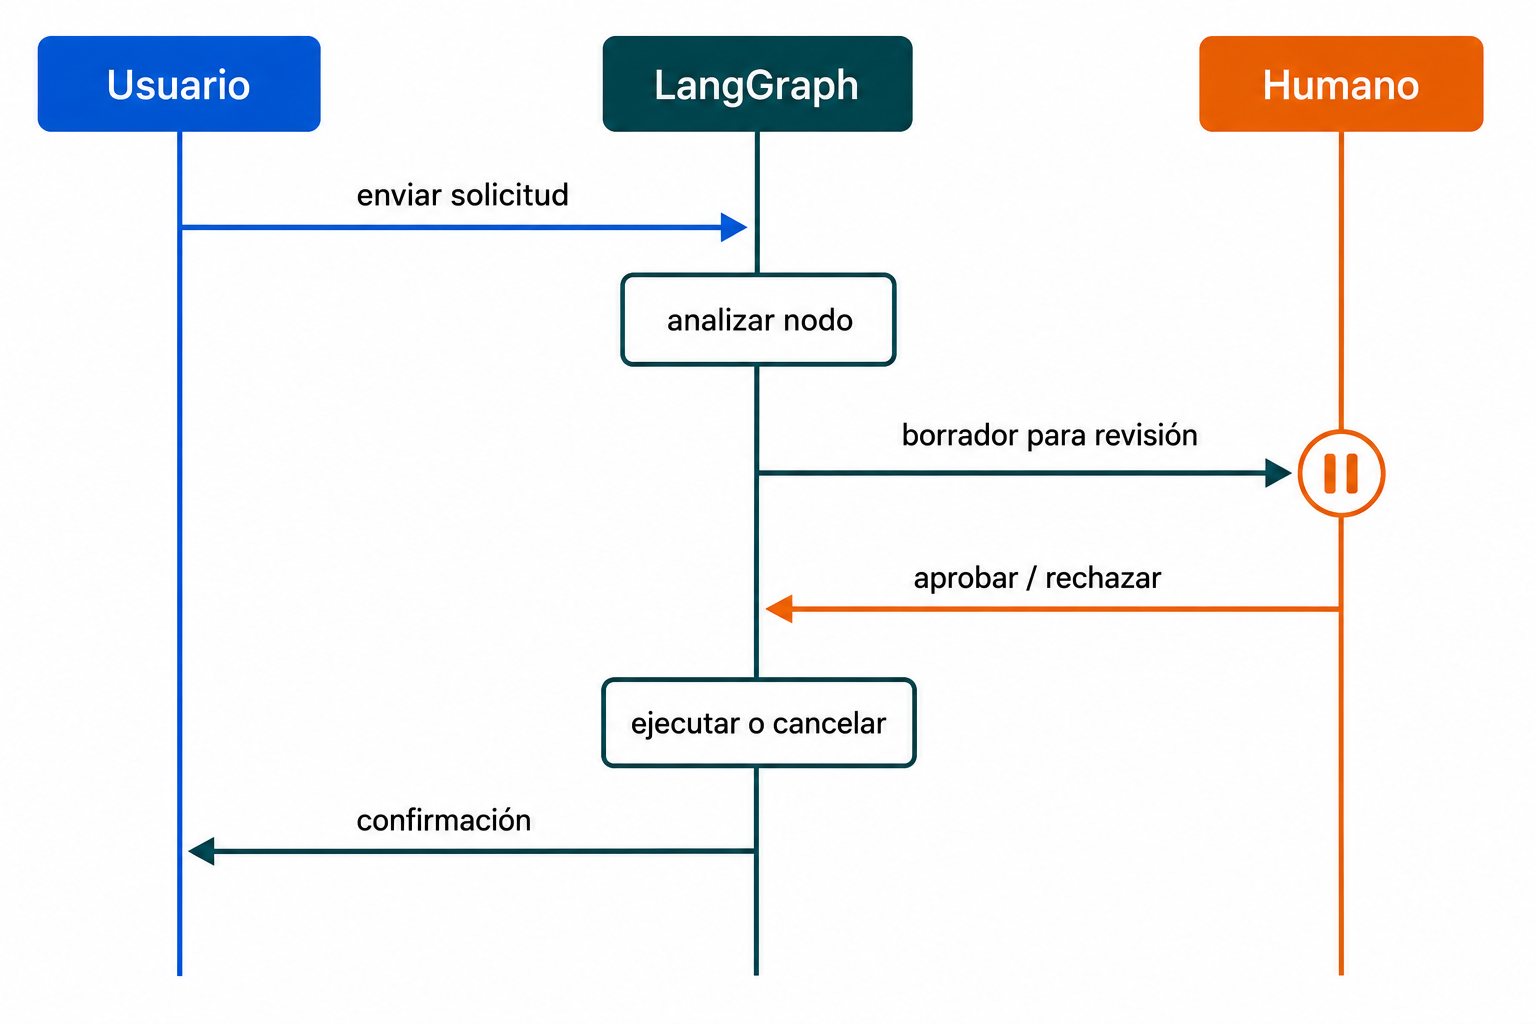

`interrupt_after=["analizar"]` pausa el grafo. `update_state()` es la firma del humano. `invoke(None)` reanuda desde el checkpoint.

In [56]:
from langgraph.checkpoint.memory import MemorySaver

class EstadoOrden(TypedDict):
    messages: Annotated[list, add_messages]
    orden:    str   # la orden propuesta por el agente
    aprobada: bool

def analizar(state: EstadoOrden) -> dict:
    orden = "COMPRAR 10 acciones de NVDA a $118.30 — total: $1,183.00"
    print(f"  [agente] propuesta: {orden}")
    return {
        "orden": orden,
        "messages": [AIMessage(content=f"Propongo: {orden}. ¿Apruebas?")]
    }

def ejecutar(state: EstadoOrden) -> dict:
    print(f"  [agente] ejecutando: {state['orden']}")
    return {"messages": [AIMessage(content="Ejecutado. Confirmación: #TXN-00293")]}

def cancelar(state: EstadoOrden) -> dict:
    return {"messages": [AIMessage(content="Cancelado. No se realizó ninguna operación.")]}

def decidir(state: EstadoOrden) -> str:
    return "ejecutar" if state.get("aprobada") else "cancelar"

checkpointer = MemorySaver()
g2 = StateGraph(EstadoOrden)
g2.add_node("analizar", analizar)
g2.add_node("ejecutar", ejecutar)
g2.add_node("cancelar", cancelar)
g2.set_entry_point("analizar")
g2.add_conditional_edges("analizar", decidir, {"ejecutar": "ejecutar", "cancelar": "cancelar"})
g2.add_edge("ejecutar", END)
g2.add_edge("cancelar", END)

# interrupt_after pausa el grafo justo después del nodo "analizar"
app2 = g2.compile(checkpointer=checkpointer, interrupt_after=["analizar"])
print("Grafo HITL compilado.")

Grafo HITL compilado.


In [57]:
config = {"configurable": {"thread_id": "orden-001"}}

# Paso 1: el agente analiza y el grafo se pausa
print("=== PASO 1: el agente propone ===")
estado = app2.invoke(
    {"messages": [HumanMessage(content="Compra NVDA para mi cartera")], "aprobada": False},
    config=config
)
print(estado["messages"][-1].content)
print("\n>>> GRAFO PAUSADO <<<")

# Paso 2: el humano aprueba modificando el estado
print("\n=== PASO 2: el humano aprueba ===")
app2.update_state(config, {"aprobada": True})

# Paso 3: reanudamos desde el checkpoint
resultado = app2.invoke(None, config=config)  # None = continuar desde donde se quedó
print(resultado["messages"][-1].content)

=== PASO 1: el agente propone ===
  [agente] propuesta: COMPRAR 10 acciones de NVDA a $118.30 — total: $1,183.00
Propongo: COMPRAR 10 acciones de NVDA a $118.30 — total: $1,183.00. ¿Apruebas?

>>> GRAFO PAUSADO <<<

=== PASO 2: el humano aprueba ===
  [agente] ejecutando: COMPRAR 10 acciones de NVDA a $118.30 — total: $1,183.00
Ejecutado. Confirmación: #TXN-00293


## Sección 6 — LangSmith: observabilidad

> **Esta sección es opcional.** Solo funciona si ejecutaste la celda de LangSmith al inicio (la de `LANGSMITH_TRACING = "true"`). Si no la ejecutaste, sáltate esta sección — el resto del notebook funciona igual.

---

**¿Qué es LangSmith?**

Es la herramienta de observabilidad nativa del ecosistema LangChain. El equivalente a lo que vimos con **Langfuse** y **Arize Phoenix**, pero integrada de serie — se activa con 3 variables de entorno sin tocar ninguna línea de tu código.

Lo que te da:
- **Trazas** — cada llamada al LLM, cada tool call, cada nodo del grafo, con latencia y tokens
- **Feedback** — puedes puntuar respuestas para construir un dataset de evaluación
- **Datasets y evals** — guarda ejemplos reales y corre evaluaciones automáticas cuando cambias el prompt o el modelo

Si lo activaste al principio, **todas las ejecuciones anteriores de este notebook ya están trazadas** en [smith.langchain.com](https://smith.langchain.com) → proyecto EBIS-lab.

In [58]:
from langsmith import Client

ls_client = Client()

runs = list(ls_client.list_runs(
    project_name="EBIS-lab",
    limit=5,
    filter='eq(is_root, true)'
))

print(f"Últimas {len(runs)} ejecuciones:\n")
for run in runs:
    tokens  = (run.prompt_tokens or 0) + (run.completion_tokens or 0)
    latencia = f"{run.latency:.1f}s" if run.latency else "?"
    print(f"  [{run.run_type}] {run.name}")
    print(f"    Tokens: {tokens} | Latencia: {latencia} | Status: {run.status}")
    print()

LangSmithError: Failed to GET /sessions in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/sessions?limit=1&name=EBIS-lab&include_stats=False', '{"detail":"Forbidden"}')

In [ ]:
# Añadir feedback a una traza — la base de los evals
if runs:
    ls_client.create_feedback(
        run_id=runs[0].id,
        key="correctness",
        score=1,
        comment="Respuesta correcta y usó las herramientas bien."
    )
    print("Feedback añadido. Ábrelo en smith.langchain.com")
else:
    print("Sin trazas aún — asegúrate de que LANGSMITH_TRACING=true y ejecuta las celdas anteriores.")

In [ ]:
# Crear un dataset de evaluación con ejemplos reales
nombre_dataset = "EBIS-financiero-evals"

try:
    dataset = ls_client.create_dataset(nombre_dataset,
                                       description="Preguntas financieras para evaluar el agente")
    print(f"Dataset creado: {dataset.id}")
except Exception:
    dataset = ls_client.read_dataset(dataset_name=nombre_dataset)
    print(f"Dataset existente: {dataset.id}")

ejemplos = [
    {"input": {"input": "¿Cuánto vale AAPL?"},       "output": {"output": "AAPL: $213.5"}},
    {"input": {"input": "Compara AAPL y MSFT"},      "output": {"output": "AAPL: $213.5 | MSFT: $415.8"}},
]

ls_client.create_examples(
    inputs=[e["input"] for e in ejemplos],
    outputs=[e["output"] for e in ejemplos],
    dataset_id=dataset.id
)
print(f"{len(ejemplos)} ejemplos añadidos al dataset.")

## Sección 7 — Ejercicio

Construye un agente LangGraph con al menos 2 herramientas propias y un edge condicional.

**Ideas de dominio** (elige una o inventa la tuya):
- Agente de soporte IT: clasifica el ticket → busca solución → propone → pide aprobación
- Agente de contenido: recibe tema → redacta → evalúa calidad → mejora si es bajo
- Agente de datos: pregunta en lenguaje natural → genera SQL → ejecuta → interpreta

**Estructura mínima**: TypedDict con 3+ campos · 2+ nodos · 1 edge condicional · 1+ `@tool`

In [ ]:
# Tu código aquí
# Pista: empieza por el Estado, luego las tools, luego los nodos, luego el grafo

# from typing import TypedDict, Annotated
# from langgraph.graph import StateGraph, END
# from langgraph.graph.message import add_messages
# from langchain_core.tools import tool

# class MiEstado(TypedDict):
#     messages: Annotated[list, add_messages]
#     ...

pass